In [54]:
import tensorflow
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os
import numpy as np
import matplotlib.pyplot as plt


Verif que tensorflow fonctionne bien :

In [55]:
print("TensorFlow version:", tensorflow.__version__)
gpus = tensorflow.config.list_physical_devices('GPU')

if gpus:
    print(f"TensorFlow utilise : {gpus[0].name}")
    print("Détails :", gpus)
else:
    print("TensorFlow tourne sur le processeur (CPU).")

TensorFlow version: 2.20.0
TensorFlow utilise : /physical_device:GPU:0
Détails : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [56]:
import os

# Ton dossier cible (vérifie que c'est le bon, ex: 'data_elite' ou 'data/images')
target_dir = 'data/images' 

print(f"--- Comptage des images dans {target_dir} ---\n")

stats = {}

# On parcourt les dossiers
if os.path.exists(target_dir):
    for race in os.listdir(target_dir):
        race_path = os.path.join(target_dir, race)
        if os.path.isdir(race_path):
            # On compte les fichiers
            count = len(os.listdir(race_path))
            stats[race] = count

    # On trie pour voir les déséquilibres (du + grand au + petit)
    for race, count in sorted(stats.items(), key=lambda item: item[1], reverse=True):
        print(f"{race.ljust(25)} : {count} images")
else:
    print(f"Le dossier {target_dir} n'existe pas !")

--- Comptage des images dans data/images ---

Domestic Short Hair       : 53027 images
Domestic Medium Hair      : 5482 images
American Shorthair        : 5295 images
Domestic Long Hair        : 4499 images
Persian                   : 4018 images
Tortoiseshell             : 3963 images
Calico                    : 3468 images
Torbie                    : 3396 images
Dilute Calico             : 3230 images
Tuxedo                    : 3181 images
Dilute Tortoiseshell      : 3152 images
Tabby                     : 3012 images
Siamese                   : 2888 images
Ragdoll                   : 2669 images
Bengal                    : 2477 images
Tiger                     : 2256 images
Manx                      : 2059 images
Russian Blue              : 1870 images
Bombay                    : 1835 images
Snowshoe                  : 1625 images
Maine Coon                : 1418 images
Himalayan                 : 1301 images
Extra-Toes Cat - Hemingway Polydactyl : 1184 images
American Bobtail     

In [ ]:
import os
import shutil
import random

# --- CONFIGURATION ---
source_dir = 'data/images'       # Ton dossier original avec les 67 classes
target_dir = 'data_clean'     # Le nouveau dossier PROPRE
LIMIT_IMAGES = 600               # On aligne tout le monde sur le plus petit (British Shorthair)

# La sélection des 15 races valides (>500 images)
races_choisies = [
    'American Shorthair',
    'Persian',
    'Siamese',
    'Ragdoll',
    'Bengal',
    'Manx',
    'Russian Blue',
    'Bombay',
    'Snowshoe',
    'Maine Coon',
    'Himalayan',
    'American Bobtail',
    'Turkish Van',
    'Turkish Angora',
    'British Shorthair'
]

print(f"Préparation du dataset équilibré à {LIMIT_IMAGES} images...")

if os.path.exists(target_dir):
    shutil.rmtree(target_dir)
os.makedirs(target_dir)

total_images = 0

for race in races_choisies:
    src_path = os.path.join(source_dir, race)
    dst_path = os.path.join(target_dir, race)
    
    if os.path.exists(src_path):
        os.makedirs(dst_path)
        all_images = os.listdir(src_path)
        
        # Mélange pour la variété
        #random.shuffle(all_images)
        
        # On coupe
        images_a_garder = all_images[:LIMIT_IMAGES]
        
        for img in images_a_garder:
            shutil.copy(os.path.join(src_path, img), os.path.join(dst_path, img))
            
        count = len(images_a_garder)
        total_images += count
        print(f"{race.ljust(20)} : {count} images")
    else:
        print(f"MANQUANT : {race}")

print(f"\nTerminé ! Dataset prêt dans '{target_dir}' avec {total_images} images.")

Préparation du dataset 'TOP 15' équilibré à 600 images...
American Shorthair   : 600 images
Persian              : 600 images
Siamese              : 600 images
Ragdoll              : 600 images
Bengal               : 600 images
Manx                 : 600 images
Russian Blue         : 600 images
Bombay               : 600 images
Snowshoe             : 600 images
Maine Coon           : 600 images
Himalayan            : 600 images
American Bobtail     : 600 images
Turkish Van          : 600 images
Turkish Angora       : 600 images
British Shorthair    : 567 images

Terminé ! Dataset prêt dans 'data_clean' avec 8967 images.


In [60]:
data_dir = 'data_clean'

BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

print(f"Chargement des images depuis : {data_dir}")

# On charge les données d'entraînement (80%)
train_ds = tensorflow.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE
)

# On charge les données de validation (20%)
val_ds = tensorflow.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE
)

# On récupère les noms des races trouvées
class_names = train_ds.class_names
print(f"\nRaces trouvées ({len(class_names)}) : {class_names}")

Chargement des images depuis : data_clean
Found 8967 files belonging to 15 classes.
Using 7174 files for training.
Found 8967 files belonging to 15 classes.
Using 1793 files for validation.

Races trouvées (15) : ['American Bobtail', 'American Shorthair', 'Bengal', 'Bombay', 'British Shorthair', 'Himalayan', 'Maine Coon', 'Manx', 'Persian', 'Ragdoll', 'Russian Blue', 'Siamese', 'Snowshoe', 'Turkish Angora', 'Turkish Van']


Création de variations aléatoire des images pour éviter l'apprentissage par coeur du modèle (data augmentation)

In [61]:
data_augmentation = tensorflow.keras.Sequential([
  layers.RandomFlip("horizontal", input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
  layers.RandomRotation(0.1), # Pivote l'image de 10% max
  layers.RandomZoom(0.1),     # Zoom avant/arrière de 10% max
])

/home/simon/IAproject/.venv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [62]:
nbr_classes = len(class_names)

model = models.Sequential([
  data_augmentation,
  
  # Normalisation entre 0 et 1
  layers.Rescaling(1./255),
  
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Dropout(0.2),
  
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(nbr_classes)
])

model.compile(optimizer='adam', loss=tensorflow.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_16 (Sequential)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_11 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,448,175 (24.60 MB)

 Trainable params: 6,448,175 (24.60 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
# Entrainement du modèle
epochs = 10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10


E0000 00:00:1769615357.390124    1138 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_17_1/dropout_11_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


225/225 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - accuracy: 0.1353 - loss: 2.6217 - val_accuracy: 0.1668 - val_loss: 2.5412
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.1805 - loss: 2.4855 - val_accuracy: 0.1835 - val_loss: 2.4758
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.2117 - loss: 2.4047 - val_accuracy: 0.2069 - val_loss: 2.4134
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.2216 - loss: 2.3716 - val_accuracy: 0.2097 - val_loss: 2.3847
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.2311 - loss: 2.3285 - val_accuracy: 0.2186 - val_loss: 2.3769
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.2480 - loss: 2.2980 - val_accuracy: 0.2136 - val_loss: 2.3968
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.2520 - loss: 2.2868 - val_accuracy: 0.2253 - val_loss: 2.3841
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.2572 - loss: 2.2621 - val_accurac

In [64]:
# Sauvegarde du modèle
model.save('backend/model_custom.keras')
print("Le modèle a bien été sauvegardé.")

Le modèle a bien été sauvegardé.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


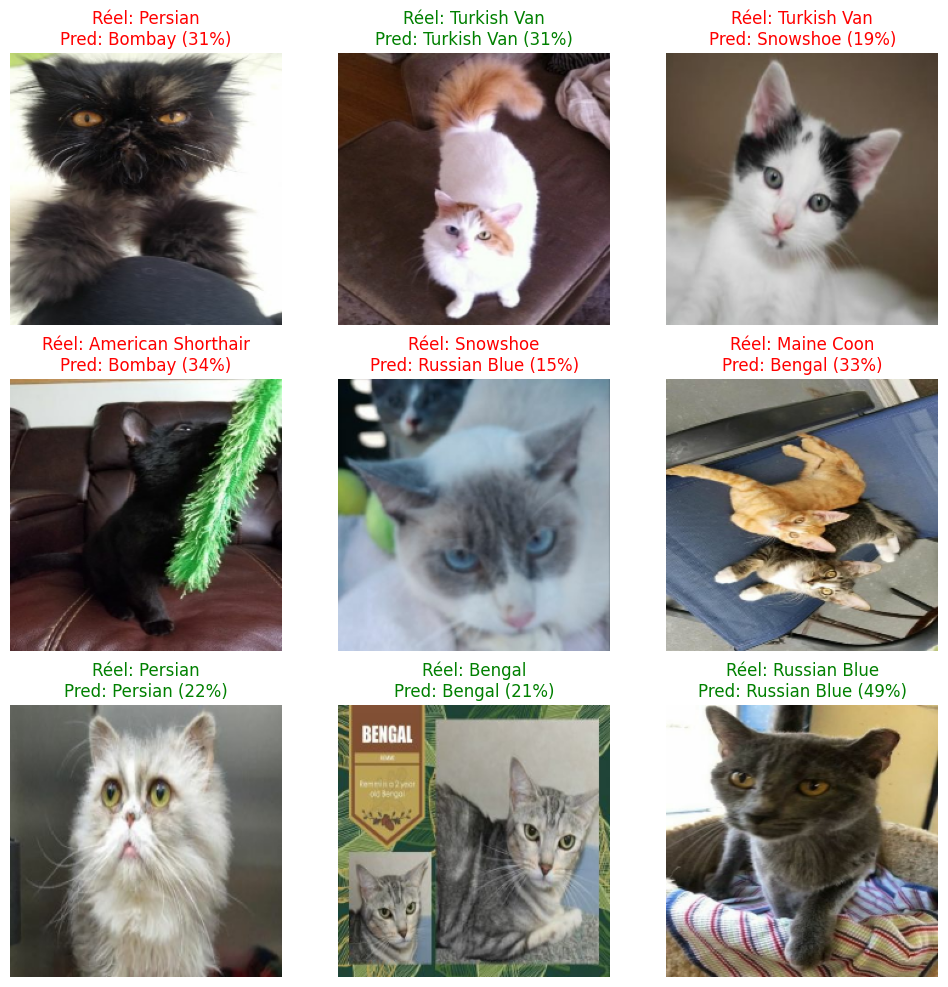

In [66]:
# On récupère un lot d'images de validation
image_batch, label_batch = next(iter(val_ds))

# Prédictions
predictions = model.predict(image_batch)

# Affichage des résultats
plt.figure(figsize=(12, 12))
for i in range(9): # On affiche les 9 premières
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].numpy().astype("uint8"))
  
  # Calcul du score
  scores = tensorflow.nn.softmax(predictions[i])
  predicted_class = class_names[np.argmax(scores)]
  confidence = 100 * np.max(scores)
  
  real_class = class_names[label_batch[i]]
  
  color = 'green' if predicted_class == real_class else 'red'
  
  plt.title(f"Réel: {real_class}\nPred: {predicted_class} ({confidence:.0f}%)", color=color)
  plt.axis("off")

plt.show()

## Approche transfert learning

In [ ]:
# 1. On télécharge le cerveau pré-entraîné (sans la tête)
base_model = tensorflow.keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)

# 2. On "gèle" le modèle de base (on ne veut pas modifier ce qu'il sait déjà)
base_model.trainable = False

# 3. On construit notre modèle par-dessus
model_tl = models.Sequential([
    # Data Augmentation (toujours utile)
    layers.RandomFlip("horizontal", input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    
    # Le modèle Google (Normalisation des pixels est intégrée dedans pour MobileNet)
    # Note: MobileNet attend des pixels entre -1 et 1, on ajoute une couche de preprocess
    layers.Rescaling(1./127.5, offset=-1), 
    
    base_model,
    
    # Notre tête de classification
    layers.GlobalAveragePooling2D(), # Plus moderne que Flatten pour le Transfer Learning
    layers.Dropout(0.2),
    layers.Dense(nbr_classes) # Nos 9 races
])

# 4. Compilation
model_tl.compile(optimizer=tensorflow.keras.optimizers.Adam(learning_rate=0.001), # Learning rate plus faible pour fignoler
              loss=tensorflow.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model_tl.summary()

# 5. Entraînement
print("Lancement du Transfer Learning...")
epochs_tl = 15
history_tl = model_tl.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs_tl
)

In [70]:
# Sauvegarde du modèle
model_tl.save('backend/model_tl.keras')
print("Le modèle a bien été sauvegardé.")

Le modèle a bien été sauvegardé.


In [ ]:
# --- PHASE 2 : FINE-TUNING (L'arme secrète) ---

# 1. On dégèle le modèle de base
base_model.trainable = True

print(f"Nombre total de couches dans MobileNetV2 : {len(base_model.layers)}")

# 2. On ne veut pas tout ré-entraîner (trop risqué), juste la fin
# On gèle les 100 premières couches, on laisse les 50 dernières libres
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. RE-COMPILATION OBLIGATOIRE (Règle d'or)
# ⚠️ TRES IMPORTANT : Le Learning Rate doit être MINUSCULE (1e-5)
# Si tu gardes 0.001, tu vas "casser" tout ce que le modèle sait déjà.
model_tl.compile(loss=tensorflow.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer = tensorflow.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

model_tl.summary()

# 4. On relance l'entraînement (en continuant l'histoire)
print("🚀 Lancement du Fine-Tuning (Mode Micro-Chirurgie)...")

total_epochs = 15 + 10 # Les 15 d'avant + 10 nouvelles = 25 total

history_fine = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=history_tl.epoch[-1], # On reprend là où on s'est arrêté
    epochs=total_epochs
)

Nombre total de couches dans MobileNetV2 : 154


NameError: name 'tf' is not defined